# **(ADD HERE THE NOTEBOOK NAME)**

## Objectives

* Explore the visual characteristics of healthy and powdery mildew cherry leaves.

* Create image montages for both categories.

* Generate average and variability images for each category.

* Compare average images to investigate visual differences between the classes.

* Record findings relevant to the client's first business requirement.

## Inputs

* Cherry-leaf dataset from data/raw/cherry-leaves/cherry-leaves/

* 2,104 healthy images and 2,104 powdery mildew images

* Images measuring 256 × 256 pixels

## Outputs

* Sample image visualisations

* Image montages for both categories

* Average and variability images

* Comparison visualisations

* Written observations and findings

## Additional Comments

* In case you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/FInal-Project-01/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/workspaces/FInal-Project-01'

# Section 1

Section 1 content

In [5]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

dataset_path = Path("data/raw/cherry-leaves/cherry-leaves")

healthy_path = dataset_path / "healthy"
mildew_path = dataset_path / "powdery_mildew"

print("Healthy folder exists:", healthy_path.exists())
print("Powdery mildew folder exists:", mildew_path.exists())

Healthy folder exists: True
Powdery mildew folder exists: True


---

# Section 2

Section 2 content

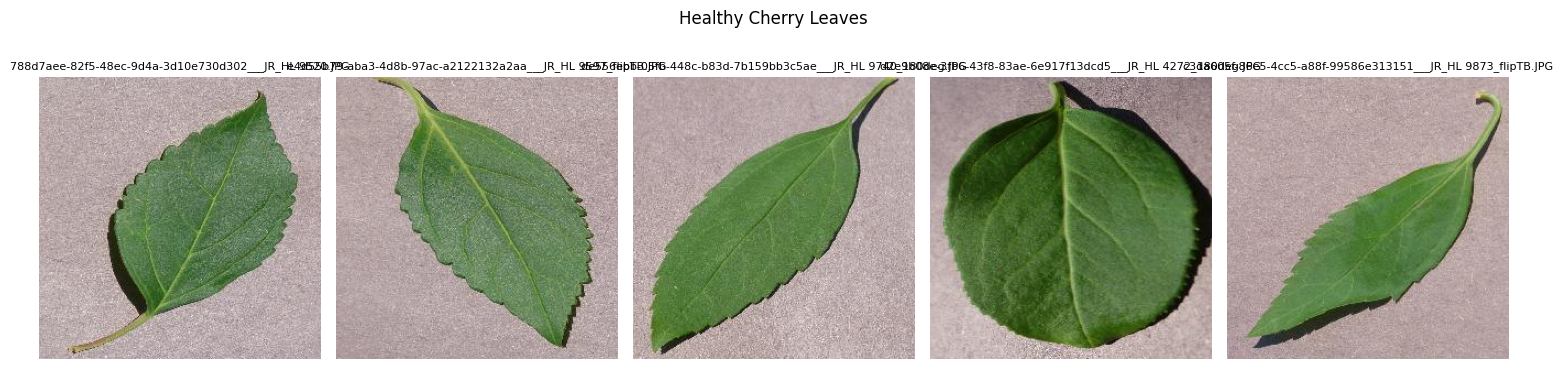

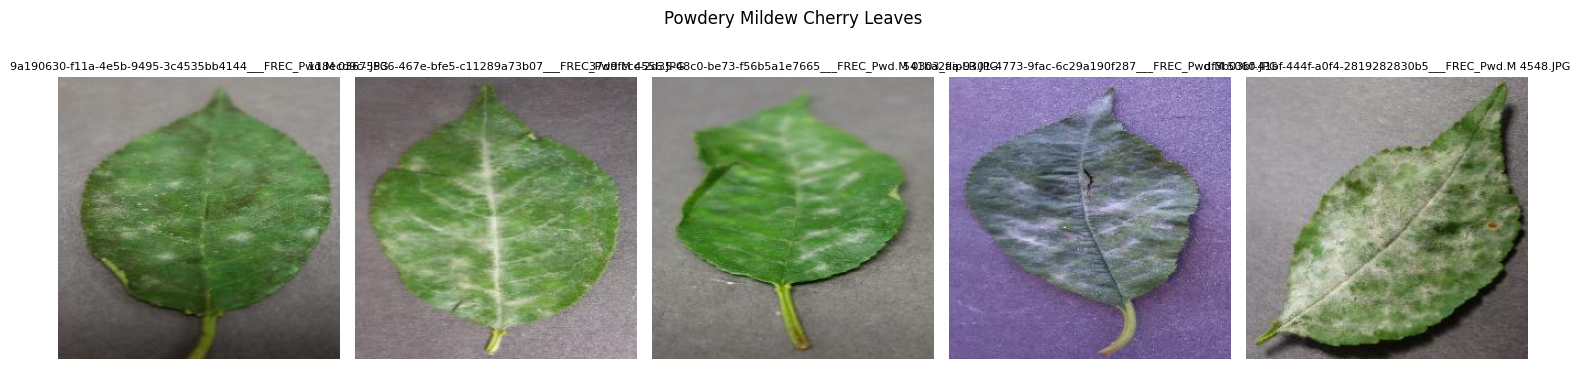

In [8]:
def display_sample_images(folder, category, sample_size=5):
    image_files = sorted(folder.glob("*.png"))

    if not image_files:
        image_files = sorted(folder.glob("*.JPG"))

    selected_images = random.sample(
        image_files,
        min(sample_size, len(image_files))
    )

    fig, axes = plt.subplots(1, len(selected_images), figsize=(15, 4))

    for ax, image_path in zip(axes, selected_images):
        with Image.open(image_path) as image:
            ax.imshow(image.convert("RGB"))

        ax.set_title(image_path.name, fontsize=8)
        ax.axis("off")

    plt.suptitle(f"{category} Cherry Leaves")
    plt.tight_layout()
    plt.show()


display_sample_images(healthy_path, "Healthy")
display_sample_images(mildew_path, "Powdery Mildew")

---

In [7]:
print("First 5 healthy files:")
print([file.name for file in list(healthy_path.iterdir())[:5]])

print("\nFirst 5 powdery mildew files:")
print([file.name for file in list(mildew_path.iterdir())[:5]])

First 5 healthy files:
['3ed044bb-34e5-4ceb-8dc5-215534cb3e6e___JR_HL 9849.JPG', 'e4a4adf6-5ad5-420f-bab7-64812af0ac2d___JR_HL 3977_180deg.JPG', '68f0e459-0938-4988-862f-893afb413d57___JR_HL 4268_flipTB.JPG', '9f57292a-576b-4ae8-a71a-cdaf42bcd6b7___JR_HL 9861_180deg.JPG', '484ade57-5dd0-4764-b379-5a0e684afd81___JR_HL 9580.JPG']

First 5 powdery mildew files:
['5bff6ee9-60ba-46d9-82a6-637458ebb8b0___FREC_Pwd.M 0483.JPG', 'bc3b4287-ce7a-4ca1-bfa8-4812832fa00f___FREC_Pwd.M 0412_flipLR.JPG', '5d785df7-f03c-4a2d-be73-567831c490a8___FREC_Pwd.M 4616_flipLR.JPG', '7899bce2-cd7e-4f46-b636-a7b350d2c9cb___FREC_Pwd.M 4585_flipLR.JPG', '65972389-76f0-4b7a-ac4d-b2e9d6dc8d67___FREC_Pwd.M 4664.JPG']


<Figure size 1500x400 with 0 Axes>

NOTE

In [9]:
def create_image_montage(folder, category, rows=4, cols=4):
    supported_extensions = {".jpg", ".jpeg", ".png", ".webp"}

    image_files = [
        file for file in folder.iterdir()
        if file.is_file() and file.suffix.lower() in supported_extensions
    ]

    sample_size = rows * cols

    if len(image_files) < sample_size:
        print(f"Not enough images in {category} folder.")
        return

    selected_images = random.sample(image_files, sample_size)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))

    for ax, image_path in zip(axes.flat, selected_images):
        with Image.open(image_path) as image:
            ax.imshow(image.convert("RGB"))

        ax.axis("off")

    fig.suptitle(
        f"{category} Cherry Leaves — Image Montage",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

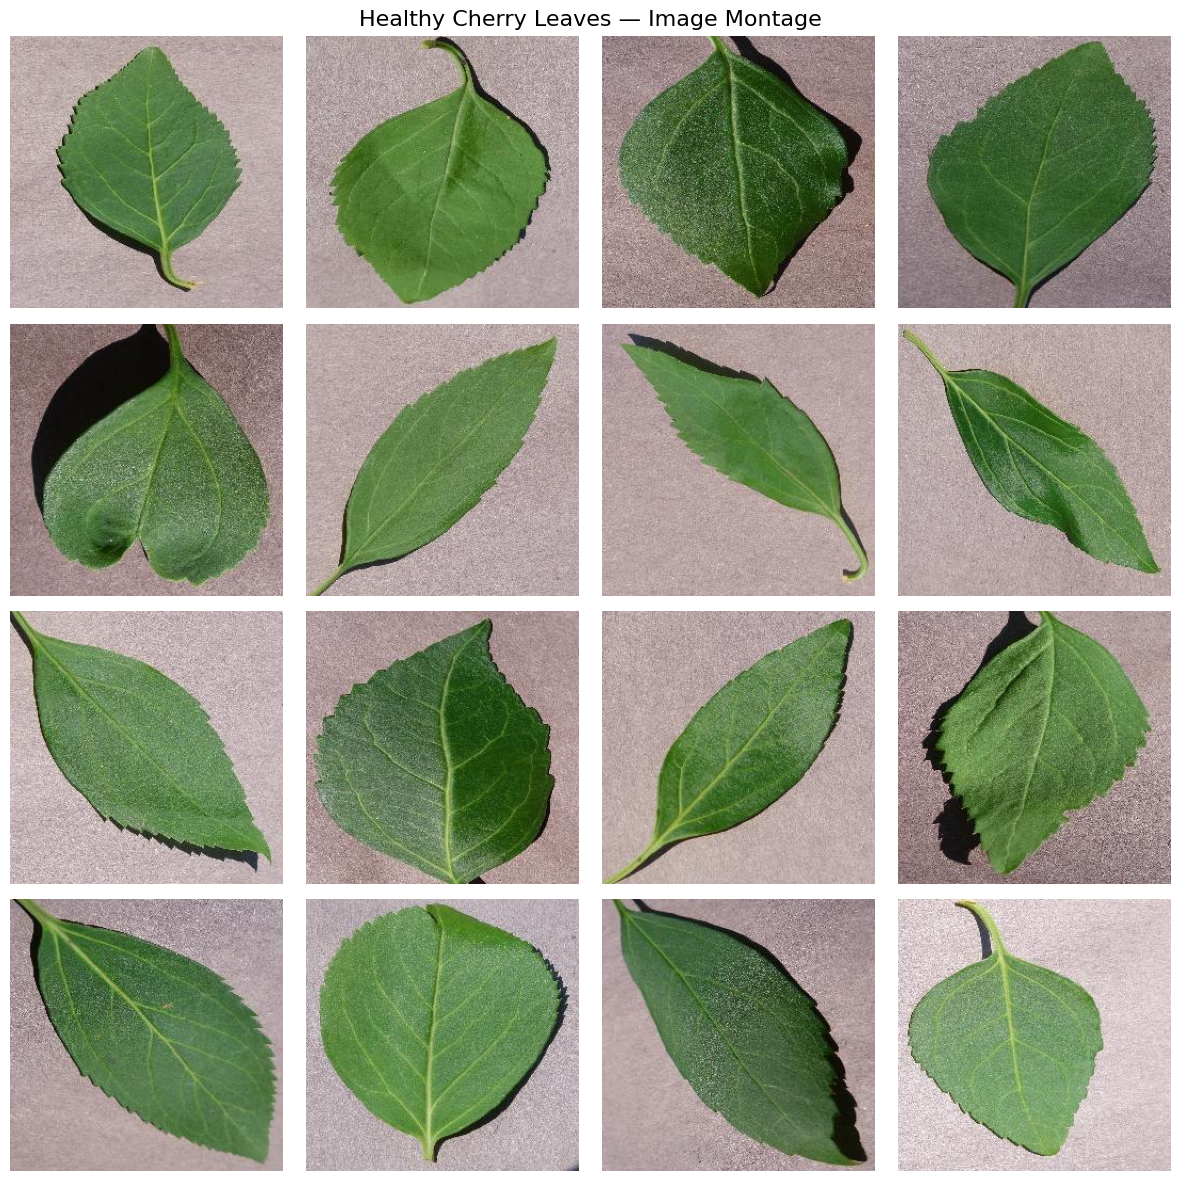

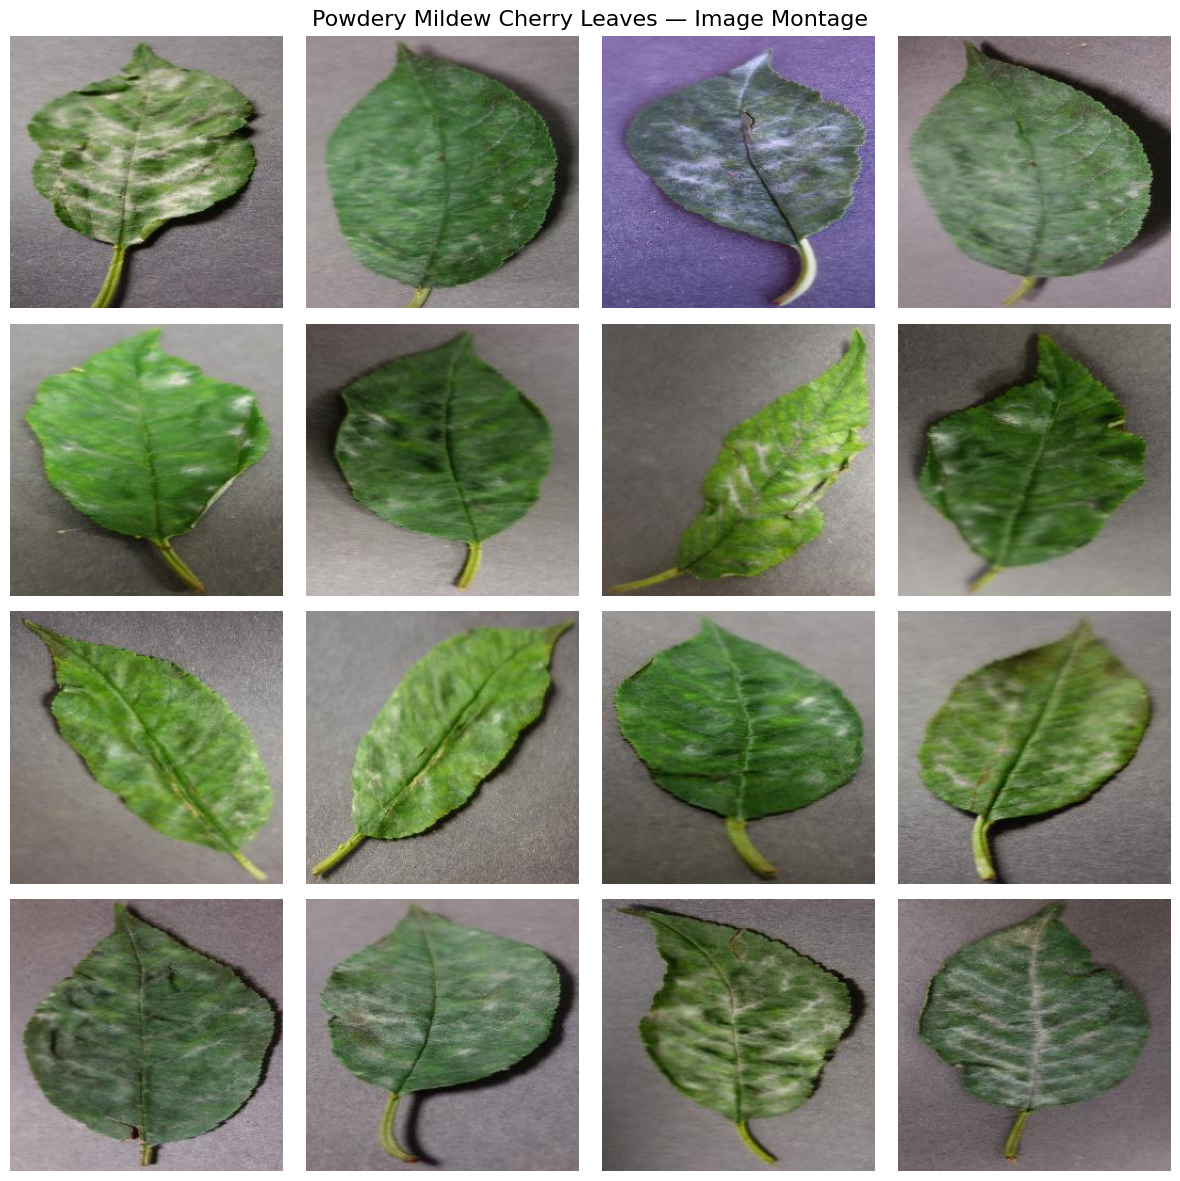

In [10]:
create_image_montage(healthy_path, "Healthy")
create_image_montage(mildew_path, "Powdery Mildew")

In [11]:
def calculate_average_image(folder):
    supported_extensions = {".jpg", ".jpeg", ".png", ".webp"}

    image_files = [
        file for file in folder.iterdir()
        if file.is_file() and file.suffix.lower() in supported_extensions
    ]

    image_arrays = []

    for image_path in image_files:
        with Image.open(image_path) as image:
            image_array = np.array(
                image.convert("RGB"),
                dtype=np.float32
            )

        image_arrays.append(image_array)

    average_image = np.mean(image_arrays, axis=0)

    return average_image

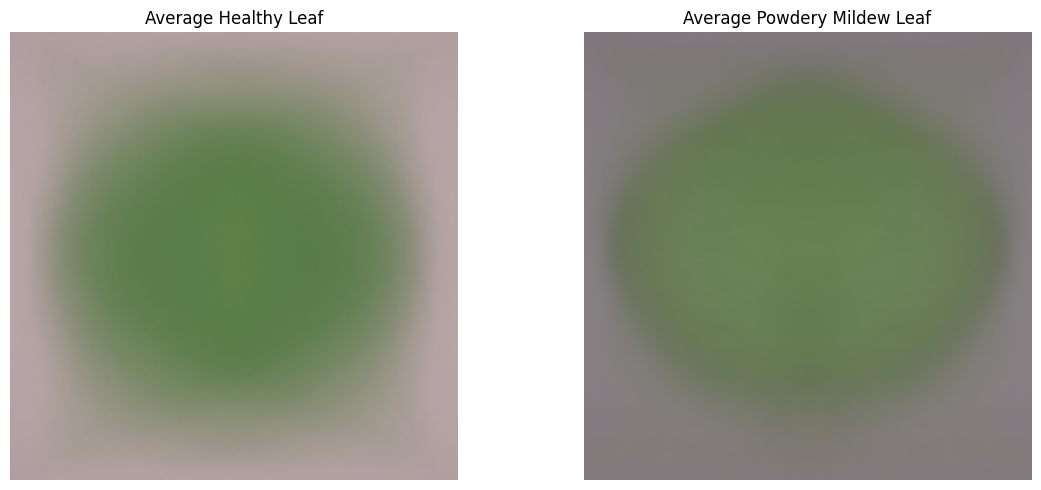

In [12]:
healthy_average = calculate_average_image(healthy_path)
mildew_average = calculate_average_image(mildew_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(healthy_average.astype(np.uint8))
axes[0].set_title("Average Healthy Leaf")
axes[0].axis("off")

axes[1].imshow(mildew_average.astype(np.uint8))
axes[1].set_title("Average Powdery Mildew Leaf")
axes[1].axis("off")

plt.tight_layout()
plt.show()

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* If you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
    # create here your folder
    # os.makedirs(name='')
except Exception as e:
    print(e)
